# Нейронные сети
# Обучение нейронной сети

Рассмотрим обучение нейронной сети. Построим вначале бинарный, а затем мультиклассовый классификатор.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score

## Подготовка данных

Импортируем данные о вине, удалим класс 2, из признаков оставим спирт и пролин, масштабируем данные.

In [2]:
# импортируем датасет
from sklearn import datasets
data = datasets.load_wine()

# сформируем датафрейм и добавим целевую переменную
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

# удалим класс 2
df = df[df.target != 2]

# оставим только спирт и пролин
X = df[['alcohol', 'proline']]
y = df['target']

# масштабируем признаки
X = (X - X.mean()) / X.std()

# посмотрим на размерность и оставшиеся классы
df.shape, df.target.unique()

((130, 14), array([0, 1]))

Дополнительно преобразуем датафрейм признаков X в массив Numpy с размерностью 2 x 130 и сделаем целевую переменную y двумерным массивом.

In [3]:
# каждый столбец - это одно наблюдение
X = X.to_numpy().T
X.shape

(2, 130)

In [4]:
y = y.to_numpy().reshape(1, -1)
y.shape

(1, 130)

## Нейросеть без смещения
## Архитектура сети
Пойдем от простого к сложному и на первом этапе создадим алгоритм для бинарной классификации без смещения.
![](https://drive.google.com/uc?export=view&id=1GUctyH6bu7fMprl_ddLRGHC5uRITZT6C  )
Итак, сеть будет состоять из следующих слоев:
* входной слой $A^{(1)}$ из двух нейронов $a^{(1)}_1$ и $a^{(1)}_2,$ т.е. двух признаков, на основе которых мы будем предсказывать класс вина;
* один скрытый слой $A^{(2)},$ состоящий из трех нейронов: $a^{(2)}_1$, $a^{(2)}_2$ и $a^{(2)}_3;$ и
* выходной слой из одного нейрона $a^{(3)},$ т.е. вероятности принадлежности к одному из двух классов.

Заглавной буквой, например, $A^{(1)}$ обозначаются сразу все нейроны, в данном случае, входного слоя, строчной с соответствющим индексом $a^{(1)}_1$ — отдельный нейрон этого слоя.

Также напомним, что у нас **последовательная** (sequential) архитектура сети, при которой каждый слой получает один тензор на вход и выдает также только один тензор.

Кроме этого, мы используем **полносвязные** (дословно, «плотно связанные», dense, densely connected) **слои**, где каждый нейрон одного слоя связан с каждым нейроном последующего (обратите внимание на красные и зеленые стрелки между входным и скрытым слоями).

## Размерность матриц
Алгоритм нейронной сети, в конечном счете, не более чем умножение матриц или, в общем случае, тензоров (отсюда, в частности, название библиотеки Tensorflow (https://www.tensorflow.org/),
которой мы пользовались, изучая основы нейронных сетей), и после выбора
архитектуры модели нам важно определиться с размерностью используемых нами
матриц.
## Первая матрица весов
Начнем со входного слоя, в который мы одновременно (за счет умножения матриц и векторизации кода) подадим матрицу из 130 наблюдений и двух признаков (после транспонирования размерность, напомним, была 2 x 130).

На нее мы будем умножать матрицу весов $W^{(1)} \cdot X$ или в терминологии слоев $W^{(1)} \cdot A^{(1)}.$ Как определить размерность матрицы весов? Очень просто. Нужно взглянуть на количество нейронов скрытого слоя. Их три. Значит размерность первой матрицы весов будет 3 х 2.
![](https://drive.google.com/uc?export=view&id=182Lv2SmKzlv8kmfNyY2sIOgFakwHdPU3)
Практический совет. Для того чтобы быстро найти размерность матрицы весов вспомним про две особенности умножения матриц:

* внутренние размеры, т.е. количество столбцов первой и строк второй, должны совпадать, в нашем случае 2 = 2;
* размерность результирующей матрицы будет равна внешним размерам умножаемых матриц, 3 и 130.

Итак, в скрытом слое у нас будет матрица 3 х 130, где каждый столбец — это три (активационных) нейрона для каждого из наблюдений.
### Полносвязный слой

Убедимся, что такое умножение матриц обеспечивает умножение каждого нейрона входного слоя на каждый нейрон скрытого слоя (т.е. полносвязность, density, слоев). Для простоты, предположим, что у нас только четыре наблюдения, а не 130.
![](https://drive.google.com/uc?export=view&id=1VFZTWd2nOXDtTy_Yr47L0tqxNrCKCfuP)

Рассмотрим первую операцию. Здесь веса $w_1$ и $w_4$ умножаются на нейроны входного слоя $a_1$ и $a_2$ и, таким образом, обеспечивают их «участие» в значении нейрона $a_1$ скрытого слоя. Аналогично, при второй операции за это отвечают $w_2$ и $w_5.$ Наконец третий нейрон скрытого слоя рассчитывается благодаря весам $w_3$ и $w_6$ и опять же обоим нейронам входного слоя.

Эти же операции можно посмотреть на стрелках на схеме архитектуры сети.

### Вторая матрица весов
Теперь, чтобы получить один единственный нейрон выходного слоя (вернее вектор-строку из 130 таких нейронов, 1 х 130), нам нужно новую матрицу весов $W^{(2)}$ умножить на результат скрытого слоя на $A^{(2)}.$

![](https://drive.google.com/uc?export=view&id=1BLCR-LXwfRqk77RfFEOvtG-rfQpn_bb5  )

Очевидно, это должна быть матрица 1 х 3, потому что только она даст нам нужную итоговую размерность 1 x 130.

Важная деталь. Как нейроны скрытого слоя, так и нейрон выходного слоя проходят через **функцию активации**, в данном случае, сигмоиду (на схемах выше не показана).

В целом мы только что рассмотрели прямое распространение. Давайте напишем соответствующий код.

## Код прямого распространения
Вначале объявим знакомые нам функции сигмоиды (функция активации) и логистической ошибки (функция потерь). Их место в архитектуре сети можно увидеть на схеме ниже.
![](https://drive.google.com/uc?export=view&id=1Dor9aB4_pI-OtS7IDsTwzL-7-SA-NrWG  )
Дополнительно заметим, что в нашей терминологии $z^{(1)}$ и $z^{(2)}$ — это результат умножения матрицы весов на матрицу нейронов соответствующего слоя, который мы «пропускаем» через сигмоиду $g.$ В частности, например, для скрытого слоя получается

$$ Z^{(1)} = W^{(1)} \cdot A^{(1)} $$

$$ A^{(2)} = g(Z^{(1)}) $$


### Функция активации

In [5]:
# функция активации
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

### Функция потерь

In [10]:
# функция потерь
def objective(y, y_pred):

  y_one_loss = y * np.log(y_pred + 1e-9)
  y_zero_loss = (1 - y) * np.log(1 - y_pred + 1e-9)
  return -np.mean(y_zero_loss + y_one_loss)

Теперь объявим веса и поместим признаки в нейроны скрытого слоя (исключительно ради единообразия терминологии).

### Прямое распространение

In [ ]:
# input layer: 2 nodes
# hidden layer 1: 3 nodes
# output layer: 1 node

In [6]:
# зададим точку отсчета
np.random.seed(33)

# инициализируем случайные веса,
# взятые из стандартного нормального распределения
W1 = np.random.randn(3, 2)
W2 = np.random.randn(1, 3)

# найдем количество наблюдений
n = X.shape[1]

# для единообразия терминологии
# поместим признаки в нейроны входного слоя
A1 = X

Последовательно выполним операции умножения весов на нейроны и пропустим результаты через две сигмоиды.

In [7]:
# выполним умножение матриц W1 и A1 и "пропустим" результат через сигмоиду
# в скобках указана итоговая размерность операции
Z1 = np.dot(W1, A1) # (3 x 130)
A2 = sigmoid(Z1) # (3 x 130)

# поступим аналогично с матрицами W2 и A2
Z2 = np.dot(W2, A2) # (1 x 130)
A3 = sigmoid(Z2) # (1 x 130)

# посмотрим, какую вероятность модель выдала для первого наблюдения
A3[:,0]

array([0.51555295])

Найдем ошибку при текущих весах.

In [11]:
# найдем ошибку при текущих весах
loss = objective(A3, y)
loss

np.float64(7.522291935047794)

### Обратное распространение
Теперь главный вопрос. Как обновить веса так, чтобы уменьшить ошибку?

По большому счету нам нужно рассчитать частную производную функции логистической ошибки $L$ относительно каждого веса $w_1, w_2, w_3, …, w_9$, ведь именно их мы и будем обновлять. Начнем с весов второго слоя, а именно,
$w_7, w_8, w_9,$ т.е. $W^{(2)}.$
## Частные производные весов $W^{(2)}$
Согласно правилу производной сложной функции градиент весов второго слоя примет вид

$$ \frac{\partial L}{\partial w^{(2)}} = \frac{\partial L}{\partial a^{(3)}} \odot
\frac{\partial a^{(3)} }{\partial z^{(2)}} \odot \frac{ \partial z^{(2)} }{\partial w^{(2)} }
$$

Нам нужно сделать следующее,

* вначале найти производную функции логистической ошибки $ \frac{\partial L}
{\partial a^{(3)}} ;$
* после этого производную сигмоиды $\frac{\partial a^{(3)} }{\partial z^{(2)}};$
и наконец
* линейной функции $\frac{ \partial z^{(2)} }{\partial w^{(2)} };$ затем
* перемножить эти производные.

Возможно вы заметили, что выше использовались индексы (3) и (2), индекс (3) относит активационную функцию $a^{(3)}$ к третьему выходному слою, а линейную функцию $z^{(2)}$ и веса линейной функции $ w^{(2)} $ ко второму. В такой нотации нам будет удобнее в дальнейшем рассчитывать градиенты и писать
код.

На всякий случай также уточним, что это будет поэлементное умножение или произведение Адамара (Hadamard product), которое мы будем обозначать через оператор $\odot.$

Далее, уверен, вы обратили внимание на то, что мы выполняем операции в обратном от прямого распространения порядке: сначала производная ошибки, потом сигмоиды третьего слоя, затем линейной функции второго. Именно поэтому процесс называется обратным распространением ошибки (error back propagation).

### Производная функции логистической ошибки
$$ \frac{\partial L}{\partial a^{(3)}} = \frac{\partial}{\partial a^{(3)}} \left( -y
\log(a^{(3)})-(1-y) \log(1-a^{(3)}) \right) $$

Применим правило производной разности и вынесем константы.

$$ -y \frac{\partial}{\partial a^{(3)}} \log(a^{(3)})-(1-y) \frac{\partial}{\partial a^{(3)}}
\log(1-a^{(3)}) $$

Найдем производную натурального логарифма, вынесем минус за скобку и вычтем одну дробь из другой.

$$ -\left( \frac{y}{a^{(3)}}-\frac{(1-y) }{1-a^{(3)}} \right) = \frac{a^{(3)}-y}{a^{(3)}
(1-a^{(3)})} $$

### Производная сигмоиды
Производную сигмоиды мы уже находили.

$$ \frac{\partial a^{(3)} }{\partial z^{(2)}} = g(z^{(2)}) (1-g(z^{(2)})) $$

При этом так как результат сигмоиды $ g(z^{(2)}) $ — это нейрон выходного слоя $ a^{(3)}, $ то

$$ \frac{\partial a^{(3)} }{\partial z^{(2)}} = a^{(3)} (1-a^{(3)}) $$

### Производная линейной функции

Найдем производную линейной функции, расписав умножение для каждого веса и для каждого нейрона.

$$ \frac{ \partial }{\partial w^{(2)} } \left( w_7 \times a^{(2)}_1 + w_8 \times a^{(2)}_2
+ w_9 \times a^{(2)}_3 \right) $$

Для того чтобы найти производную относительно, например, веса $w_7$, мы «замораживаем» (считаем константами, производная которых равна нулю) все веса, кроме первого и тогда

$$ w_7^{1-1} \times a^{(2)}_1 + 0 \times a^{(2)}_2 + 0 \times a^{(2)}_3 = $$

$$ 1 \times a^{(2)}_1 + 0 \times a^{(2)}_2 + 0 \times a^{(2)}_3 = a^{(2)}_1 $$

Аналогичный результат мы получим, продифференцировав относительно других весов. Тогда,

$$ \frac{ \partial z^{(2)} }{\partial w^{(2)}} = a^{(2)} $$

### Градиент относительно $W^{(2)}$
Наконец перемножим найденные производные и упростим выражение.

$$ \frac{\partial L}{\partial w^{(2)}} = \frac{a^{(3)}-y}{a^{(3)}(1-a^{(3)})} \odot
a^{(3)} (1-a^{(3)}) \odot a^{(2)} = $$

$$ (a^{(3)}-y) \odot a^{(2)} $$

В векторной нотации (и матричном умножении) получим

$$ \frac{\partial L}{\partial W^{(2)}} = (A^{(3)}-y) \cdot A^{(2)}.T \odot \frac{1}{n}
$$

Множитель $ \frac{1}{n} $ усредняет градиент на количество наблюдений.
### Дельта-правило $ \delta_2 $
Заметим, что $\frac{\partial L}{\partial a^{(3)}} \odot \frac{\partial a^{(3)} }{\partial
z^{(2)}}$ также обозначают через греческую букву «дельта», в нашем случае $\delta_2,$ и тогда градиент для обновления весов $W^{(2)},$ с учетом векторизованного кода, приобретет вид (опять же в векторной нотации)

$$ \frac{\partial L}{\partial W^{(2)}} = \delta_2 \cdot A^{(2)}.T \odot \frac{1}{n} $$

В дальнейшем использование так называемого «дельта-правила» (delta rule) упростит наш код.
### Обновление весов $W^{(2)}$

Остается только обновить веса $W^{(2)}$ в направлении антиградиента, умноженного на коэффициент скорости обучения.

$$ W^{(2)} := W^{(2)}-\alpha \odot \frac{\partial L}{\partial W^{(2)}}$$

### Частные производные весов $W^{(1)}$

Теперь нужно найти производные относительно весов $w_1, …, w_6$ или $W^{(1)}.$ И мы снова должны «раскручивать» правило производной сложной функции от функции логистической ошибки. На этот раз цепь будет более длинной.

$$ \frac{\partial L}{\partial w^{(1)}} = \frac{\partial L}{\partial a^{(3)}} \odot
\frac{\partial a^{(3)} }{\partial z^{(2)}} \odot \frac{ \partial z^{(2)} }{\partial a^{(2)} }
\odot \frac{ \partial a^{(2)} }{\partial z^{(1)} } \odot \frac{ \partial z^{(1)} }{\partial
w^{(1)} } $$

### Нахождение производных
Вспомним, что **первые два множителя** $\frac{\partial L}{\partial a^{(3)}} \odot
\frac{\partial a^{(3)} }{\partial z^{(2)}}$ мы обозначили через $\delta_2$.

Обратим внимание на **третий множитель** $ \frac{ \partial z^{(2)} }{\partial a^{(2)}} .$ В отличие от градиента весов $W^{(2)},$ где мы искали производную линейной функции относительно весов $\frac{ \partial z^{(2)} }{\partial w^{(2)} },$ здесь нас интересует частная производная относительно нейронов активационного слоя $a^{(2)}$.

Тогда в данном случае мы «замораживаем» (считаем константами) не веса, а нейроны $ a^{(2)} $ (считая веса просто числами) и, например, частная производная
относительно $a^{(2)}_1$ будет равна

$$ \frac{ \partial }{\partial a^{(2)}_1 } \left( w_7 \times a^{(2)}_1 + w_8 \times
a^{(2)}_2 + w_9 \times a^{(2)}_3 \right) $$

$$ w_7 \times 1 + w_8 \times 0 + w_9 \times 0 = w_7 $$

Аналогично находим производные относительно других нейронов. В векторной нотации,

$$ \frac{ \partial z^{(2)} }{\partial a^{(2)} } = W^{(2)}$$

Интересно, что ошибкой скрытого слоя $E_2$ (ошибкой $E_1$ была бы общая ошибка, которую мы рассчитали с помощью функции логистической ошибки) называют произведение

$$ E_2 = \frac{\partial L}{\partial a^{(3)}} \odot \frac{\partial a^{(3)} }{\partial
z^{(2)}} \odot \frac{ \partial z^{(2)} }{\partial a^{(2)} } $$

Это утверждение более понятно, если переписать (в векторной нотации) выражение выше как

$$ E_2 = W^{(2)}.T \cdot \delta_2 $$

Другими словами, мы по сути распространяем «ошибку» $ \delta_2 $ (число, скаляр)
на каждый из трех весов $W^{(2)}$.
Перейдем к **четвертому множителю** $ \frac{ \partial a^{(2)} }{\partial z^{(1)} }.$
Это снова производная сигмоиды, только уже «на слой раньше»,

$$ \frac{ \partial a^{(2)} }{\partial z^{(1)} } = g(z^{(1)}) (1-g(z^{(1)})) = a^{(2)} (1-
a^{(2)}) $$

И наконец **пятый компонент**,

$$ \frac{ \partial z^{(1)} }{\partial w^{(1)} } = a^{(1)} $$

#### Дельта-правило $ \delta_1 $

Аналогично предыдущему слою мы можем обозначить $ \frac{\partial L}{\partial
a^{(3)}} \odot \frac{\partial a^{(3)} }{\partial z^{(2)}} \odot \frac{ \partial z^{(2)} }
{\partial a^{(2)} } \odot \frac{ \partial a^{(2)} }{\partial z^{(1)} } $ как $ \delta_1 $ (то
есть мы опять взяли все множители, кроме последнего).

#### Градиент относительно $W^{(1)}$

В итоге градиент относительно весов $W^{(1)}$ имел бы вид,

$$ \frac{\partial L}{\partial W^{(1)}} = \left( E_2 \odot A^{(2)} \odot (1-A^{(2)})
\right) \cdot A^{(1)}.T \odot \frac{1}{n} $$

Или, раскрыв $E_2,$

$$ \frac{\partial L}{\partial W^{(1)}} = \left( ( W^{(2)}.T \cdot \delta_2) \odot A^{(2)}
\odot (1-A^{(2)}) \right) \cdot A^{(1)}.T \odot \frac{1}{n} $$

Или через $ \delta_1 $

$$ \frac{\partial L}{\partial W^{(1)}} = \delta_1 \cdot A^{(1)}.T \odot \frac{1}{n} $$

Обратите внимание на паттерн, градиент каждого слоя представляет собой произведение дельты на соответствующие нейроны активационного слоя, усредненное на количество наблюдений.

$$ \frac{\partial L}{\partial W^{(2)}} = \delta_2 \cdot A^{(2)}.T \odot \frac{1}{n} $$

$$ \frac{\partial L}{\partial W^{(1)}} = \delta_1 \cdot A^{(1)}.T \odot \frac{1}{n} $$

Разумеется, это правило справедливо и для большего количества скрытых слоев.

#### Обновление весов $W^{(1)}$
Обновление весов $W^{(1)}$ аналогично предыдущему слою.

$$ W^{(1)} := W^{(1)}-\alpha \odot \frac{\partial L}{\partial W^{(1)}}$$

Перейдем к коду.

## Код обратного распространения
Продолжим писать код, который мы начали создавать, изучая прямое распространение.

In [12]:
# найдем дельту весов между слоями 3 и 2
W2_delta = A3 - y # (1 x 130)

In [13]:
# обратите внимание, это одно число, как и результат
# третьего слоя A3 (мы выводим первый столбец из 130)
W2_delta[:, 0]

array([0.51555295])

In [14]:
# найдем дельту весов между слоями 1 и 2
W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 130)

In [15]:
# дельта 1 состоит уже из трех чисел, как и скрытый слой нейросети
W1_delta[:, 0]

array([-0.0099838 ,  0.06300821, -0.01243332])

In [16]:
# вспомним, что умножение дельты 2 на веса скрытого слоя W2 можно
# считать "промежуточной ошибкой" сети или ошибкой скрытого слоя
E2 = np.dot(W2.T, W2_delta)

# то есть одно число W2_delta мы "распространили" на весь скрытый слой,
# поэтому ошибка состоит из трех чисел
E2[:, 0]

array([-0.07704936,  1.03666489, -0.04989736])

In [17]:
# наконец найдем частную производную относительно весов W2
W2_derivative = np.dot(W2_delta, A2.T) / n # (1 x 3)
W2_derivative

array([[-0.03229078, -0.0351597 ,  0.07797505]])

In [18]:
# и весов W1
# (размерность опять же должна совпадать с размерностью матриц весов)
W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 3)
W1_derivative

array([[-0.00505965, -0.00447514],
       [ 0.05057238,  0.06621354],
       [-0.00678444, -0.00733266]])

In [19]:
# обновим веса (скорость обучения положим равной 0,1)
W2 = W2 - 0.1 * W2_derivative
W1 = W1 - 0.1 * W1_derivative

### Обучение модели

Теперь соединим прямое и обратное распространение и с помощью цикла произведем обучение нейронной сети.

In [20]:
np.random.seed(33)

W1 = np.random.randn(3, 2)
W2 = np.random.randn(1, 3)

epochs = 100000
learning_rate = 0.1

n = X.shape[1]

A1 = X

for i in range(epochs):

  # рассчитываем прямое распространение
  Z1 = np.dot(W1, A1) # (3 x 130)
  A2 = sigmoid(Z1) # (3 x 130)

  Z2 = np.dot(W2, A2) # (1 x 130)
  A3 = sigmoid(Z2) # (1 x 130)

  # рассчитываем ошибку
  loss = objective(A3, y)

  # находим дельту весов между слоями 3 и 2
  W2_delta = A3 - y # (1 x 130)
  # находим дельту весов между слоями 2 и 1
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 130)

  # находим частные производные
  W2_derivative = np.dot(W2_delta, A2.T)/n # (1 x 3)
  W1_derivative = np.dot(W1_delta, A1.T)/n # (3 x 3)

  # обновляем веса
  W2 = W2 - learning_rate * W2_derivative
  W1 = W1 - learning_rate * W1_derivative

  # периодически выводим количество итераций и текущую ошибку
  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    # можем добавить паузу для более аккуратного вывода
    time.sleep(0.5)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 7.522291935047794
-----------------------
Эпоха: 20000
Ошибка: 1.0093222124524572
-----------------------
Эпоха: 40000
Ошибка: 0.9954032684235384
-----------------------
Эпоха: 60000
Ошибка: 0.9173319445520609
-----------------------
Эпоха: 80000
Ошибка: 0.8744930971601814
-----------------------
Итоговая ошибка 0.8453306645413575
Нейросеть успешно обучена


### Прогноз и оценка качества

Сделаем прогноз и оценим качество.

In [21]:
A1 = X

Z1 = np.dot(W1, A1)
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2)
A3 = sigmoid(Z2)

# A3.flatten() делает массив одномерным,
# условие выводит True или False (1 или 0)
y_pred, y_true = A3.flatten() >= 0.5, y.flatten()

In [22]:
W1, W2

(array([[-0.21100871, -1.99383593],
        [-8.00364587,  3.80027268],
        [ 0.18945827,  1.9613264 ]]),
 array([[  6.01782106,   6.42750193, -10.96554005]]))

In [ ]:
accuracy_score(y_true, y_pred)

0.9769230769230769

## Масштабирование целевой переменной
Как мы только что убедились, градиент нейронной сети зависит от целевой переменной. Если эта переменная имеет большой диапазон, то это может создать большую ошибку при вычислении градиента, что, в свою очередь, вызовет существенное изменение весов и дестабилизирует процесс обучения.

Очевидно после обучения и прогноза целевую переменную нужно вернуть к прежнему масштабу.

### Модель в Tensorflow и Keras

Библиотека Keras представляет собой надстройку (интерфейс, API), через которую удобно создавать нейросети в библиотеке Tensorflow. Реализуем созданную выше несложную нейросеть в библиотеке Keras.

In [23]:
# в Google Colab уже установлена вторая версия библиотеки Tensorflow,
# которая существенно отличается от первой версии
import tensorflow as tf
tf.__version__

'2.19.0'

В нейросеть мы будем подавать признаки и целевую переменную таким образом, чтобы объекты были строками.

In [24]:
X.T.shape, y.T.shape

((130, 2), (130, 1))

Перейдем к созданию и обучению нейросети.

In [25]:
# зададим две точки отсчета, одну в библиотеке Numpy
np.random.seed(42)
# вторую непосредственно в Tensorflow
tf.random.set_seed(42)

# зададим архитектуру: последовательная модель
model = tf.keras.models.Sequential([
  # с полносвязными слоями
  # также укажем нейроны скрытого и выходного слоев
  # откажемся от смещения
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = False),
  tf.keras.layers.Dense(1, activation = 'sigmoid', use_bias = False)
])

# зададим особенности стохастического градиентного спуска (SGD)
# в частности, откажемся от импульса
# (подробнее об этом на других занятиях)
sgd = tf.keras.optimizers.SGD(learning_rate = 0.1,
                              momentum = 0.,
                              nesterov = False)

# соберем все вместе, дополнительно укажем тип функции потерь и метрику качества
model.compile(optimizer = sgd,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

# зададим количество эпох,
# размер batch, после которой мы обновляем веса, равен объему данных (full batch)
model.fit(X.T, y.T,
          epochs = 1000,
          batch_size = 130,
          verbose = 0)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (130, 3)               │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (130, 1)               │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Оценим качество.

In [27]:
model.history.history['accuracy'][-1]

0.9615384340286255

## Нейросеть со смещением

Добавим смещение, это должно сделать нашу модель более гибкой.
![](https://drive.google.com/uc?export=view&id=1dSnWveV5P2MZ36eH3vvnXE42qWz-Rj8y  )

В отличие от линейных моделей, мы не будем использовать одну и ту же производную и для $b$, и для $W$ (с добавлением столбца из единиц в X). Это связано с тем, что в нейросетях при обратном распространении ошибку на смещение мы *не распространяем*.

Найдем производные смещения относительно сигмоиды (последний компонент в цепи производных).

$$ \frac{ \partial z^{(2)} }{\partial b^{(2)}} = 1 $$

$$ \frac{ \partial z^{(1)} }{\partial b^{(1)}} = 1 $$

Тогда в целом, используя дельта-правило, частные производные относительно $b^{(2)}$ и $b^{(1)}$ будут равны

$$ \frac{\partial L}{\partial b^{(2)}} = \sum \delta_2 \odot \frac{1}{n} $$

$$ \frac{\partial L}{\partial b^{(1)}} = \sum \delta_1 \odot \frac{1}{n} $$

Перейдем к коду.


In [ ]:
# input layer: 2 nodes + bias
# hidden layer: 3 nodes + bias
# output layer: 1 node

In [28]:
np.random.seed(33)

# инициализируем веса
W1 = np.random.randn(3, 2)
# b1 будет иметь размерность 3 х 1,
# потому что распространяется на три нейрона скрытого слоя
b1 = np.zeros((3, 1))

W2 = np.random.randn(1, 3)
b2 = np.zeros((1, 1))

n = X.shape[1]

epochs = 100000
learning_rate = 0.1

A1 = X

for i in range(epochs):
  # 3 х 2 на 2 х 130
  Z1 = np.dot(W1, A1) + b1
  A2 = sigmoid(Z1) # (3 x 130)

  # 1 х 3 на 3 х 130
  Z2 = np.dot(W2, A2) + b2
  A3 = sigmoid(Z2) # (1 x 130)

  loss = objective(A3, y)

  W2_delta = A3 - y # (1 x 130)
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 130)

  # keepdims сохраняет исходную размерность
  # 1 х 130 на 130 х 3
  W2_derivative = np.dot(W2_delta, A2.T) / n # (1 x 3)
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n # (1 x 1)

  # 3 х 130 на 130 х 2
  W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 2)
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n # (3 x 1)

  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    time.sleep(0.5)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 7.522291935047794
-----------------------
Эпоха: 20000
Ошибка: 0.9154966777364054
-----------------------
Эпоха: 40000
Ошибка: 0.7064757011599205
-----------------------
Эпоха: 60000
Ошибка: 0.6483707479023877
-----------------------
Эпоха: 80000
Ошибка: 0.6131011807950496
-----------------------
Итоговая ошибка 0.5901468853210147
Нейросеть успешно обучена


In [29]:
Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)

y_pred, y_true = A3.flatten() > 0.5, y.flatten()

accuracy_score(y_true, y_pred)

0.9846153846153847

In [30]:
W1, W2

(array([[ 2.91122075, -6.17570063],
        [-7.94772908, -1.45843627],
        [ 5.40480187,  3.86253806]]),
 array([[ 8.6502081 ,  9.55791369, -7.45801568]]))

### **TF / Keras**. Добавим смещение в нашу модель в библиотеке Keras.

In [31]:
np.random.seed(42)
tf.random.set_seed(42)

model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = True),
  tf.keras.layers.Dense(1, activation = 'sigmoid', use_bias = True)
])

sgd = tf.keras.optimizers.SGD(learning_rate = 0.1,
                              momentum = 0.,
                              nesterov = False)

model.compile(optimizer = sgd,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(X.T, y.T,
          epochs = 1000,
          batch_size = 130,
          verbose = 0)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (130, 3)               │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (130, 1)               │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (64.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [32]:
model.history.history['accuracy'][-1]

0.9615384340286255

## Инициализация весов нулями
В моделях линейной и логистической регрессии в качестве начальных значений коэффициентов мы использовали нули, в алгоритме нейронной сети — случайные значения, почему так?
![](https://drive.google.com/uc?export=view&id=1GUctyH6bu7fMprl_ddLRGHC5uRITZT6C)

Если веса изначально равны нулю, то произойдет несколько нежелательных событий:
* значения активационных слоев $a_1^{(2)} = a_2^{(2)} = a_3^{(2)} $ будут
одинаковыми, то есть будут запоминать одну и ту же зависимость; более того
* поскольку веса между вторым и третьим (выходным) слоями будут одинаковыми, то и значения матрицы $ \delta_2 $ будут одинаковыми; а значит и
* частные производные, относящиеся к весам одного входного нейрона (например, $w_1, w_2, w_3$), будут одними и теми же.

Таким образом, после, например, двух эпох, хотя значения весов $w_1, w_2, w_3$ не будут нулевыми, они будут одинаковыми. То же можно сказать про веса $w_4,
w_5, w_6.$ И снова $a_1^{(2)} = a_2^{(2)} = a_3^{(2)}. $

Как следствие, мы существенно ограничиваем возможности (гибкость) нейронной сети запоминать сложные зависимости.

***Примечание.*** После первой эпохи веса $W^{(1)}$ будут нулевыми, потому что
матрица $W^{(2)},$ инициализированная нулями, участвует в расчете $\delta_1$

`W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2)`

и, как следствие, обнуляет $\frac{\partial L}{\partial W^{(1)}}.$

`W1_derivative = np.dot(W1_delta, A1.T) / n`

`W1 = W1 - learning_rate * W1_derivative`
После второй эпохи веса $ W^{(2)} $ уже не будут нулевыми, а значит $W^{(1)}$ обновятся.

Для наглядности инициализируем веса нулями и обучим нейросеть.

In [33]:
np.random.seed(33)

# создадим списки для учета изменения весов
W1_list, W2_list = [], []

# инициализируем веса нулями
W1 = np.zeros((3, 2))
b1 = np.zeros((3, 1))

W2 = np.zeros((1, 3))
b2 = np.zeros((1, 1))

n = X.shape[1]

epochs = 10000
learning_rate = 0.1

A1 = X

for i in range(epochs):
  Z1 = np.dot(W1, A1) + b1
  A2 = sigmoid(Z1)

  Z2 = np.dot(W2, A2) + b2
  A3 = sigmoid(Z2)

  loss = objective(A3, y)

  W2_delta = A3 - y
  # после первой эпохи, т.к. W2 инициализирована нулями,
  # W1_delta, а значит и W1 будут нулевыми
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2)

  W2_derivative = np.dot(W2_delta, A2.T) / n
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n

  W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 2)
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n

  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  # запишем веса первой и второй эпохи
  if i in [0,1]:
    W1_list.append(W1)
    W2_list.append(W2)

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    time.sleep(0.5)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 10.361632917973205
-----------------------
Эпоха: 2000
Ошибка: 1.3044115703825774
-----------------------
Эпоха: 4000
Ошибка: 1.098465006386236
-----------------------
Эпоха: 6000
Ошибка: 1.051347661092214
-----------------------
Эпоха: 8000
Ошибка: 1.0345106681993461
-----------------------
Итоговая ошибка 1.0270897575486206
Нейросеть успешно обучена


In [34]:
W1_list

[array([[0., 0.],
        [0., 0.],
        [0., 0.]]),
 array([[-2.35879595e-05, -2.41858793e-05],
        [-2.35879595e-05, -2.41858793e-05],
        [-2.35879595e-05, -2.41858793e-05]])]

In [35]:
W2_list

[array([[0.00230769, 0.00230769, 0.00230769]]),
 array([[0.00451442, 0.00451442, 0.00451442]])]

Как мы видим, нейросеть успешно обучилась, однако уровень ошибки существенно выше, чем при инициализации случайными значениями.

Заметим также, что обучение нейросети стало возможным, потому что функция сигмоиды выдает значение $0{,}5$ при нулевом аргументе. Другие функции активации, такие как ReLU или функция гиперболического тангенса, выдающие ноль при нулевом значении аргумента, сделают обучение невозможным.

Наконец скажем, что смещение можно инициализировать нулями. Это не мешает желаемому нарушению симметрии (breaking the symmetry) значений функции активации.

## Два скрытых слоя
Добавим второй скрытый слой.

In [ ]:
# input layer: 2 nodes + bias
# hidden layer 1: 3 nodes + bias
# hidden layer 2: 3 nodes + bias
# output layer: 1 node

In [36]:
np.random.seed(33)

W1 = np.random.randn(3, 2)
b1 = np.zeros((3, 1))

W2 = np.random.randn(3, 3)
b2 = np.zeros((3, 1))

W3 = np.random.randn(1, 3)
b3 = np.zeros((1, 1))

n = X.shape[1]

epochs = 10000
learning_rate = 0.1

A1 = X

for i in range(epochs):

  Z1 = np.dot(W1, A1) + b1 # (3 x 130)
  A2 = sigmoid(Z1)

  Z2 = np.dot(W2, A2) + b2 # (3 x 130)
  A3 = sigmoid(Z2)

  Z3 = np.dot(W3, A3) + b3 # (1 x 130)
  A4 = sigmoid(Z3)

  loss = objective(A4, y)

  W3_delta = A4 - y # (1 x 130)
  W2_delta = np.dot(W3.T, W3_delta) * A3 * (1 - A3) # (3 x 130)
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 130)

  # 3 х 130 на 130 х 3
  W3_derivative = np.dot(W3_delta, A3.T) / n # (3 x 3)
  b3_derivative = np.sum(W3_delta, axis = 1, keepdims = True) / n # (1 x 1)

  # 3 х 130 на 130 х 3
  W2_derivative = np.dot(W2_delta, A2.T) / n # (3 x 3)
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n # (3 x 1)

  W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 2)
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n # (3 x 1)

  W3 = W3 - learning_rate * W3_derivative
  b3 = b3 - learning_rate * b3_derivative
  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    time.sleep(1)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 11.615804428967778
-----------------------
Эпоха: 2000
Ошибка: 1.1714748013173482
-----------------------
Эпоха: 4000
Ошибка: 1.056639035973082
-----------------------
Эпоха: 6000
Ошибка: 0.994011213531446
-----------------------
Эпоха: 8000
Ошибка: 0.9212207955691606
-----------------------
Итоговая ошибка 0.8522356458660865
Нейросеть успешно обучена


In [37]:
Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)
Z3 = np.dot(W3, A3) + b3
A4 = sigmoid(Z3)

y_pred, y_true = A4.flatten() > 0.5, y.flatten()

accuracy_score(y_true, y_pred)

0.9692307692307692

Сравним с моделью в **Keras**.

In [38]:
np.random.seed(42)
tf.random.set_seed(42)

model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = True),
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = True),
  tf.keras.layers.Dense(1, activation = 'sigmoid', use_bias = True)
])

sgd = tf.keras.optimizers.SGD(learning_rate = 0.1,
                              momentum = 0.,
                              nesterov = False)

model.compile(optimizer = sgd,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(X.T, y.T,
          epochs = 1000,
          batch_size = 130,
          verbose = 0)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (130, 3)               │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (130, 3)               │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (130, 1)               │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (112.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [39]:
model.history.history['accuracy'][-1]

0.9615384340286255

## Многоклассовая классификация
Создадим нейросеть, которая будет предсказывать вероятности нескольких классов.
Во многом, идея алгоритма совпадает с softmax логистической регрессией.

### Постановка задачи и архитектура
Возьмемся за ту же задачу, которую мы решили в рамках вводного курса с помощью библиотеки Keras, а именно создадим нейросеть, которая будет распознавать рукописные цифры из датасета MNIST.

Архитектуру модели сохраним прежней.
![](https://drive.google.com/uc?export=view&id=11BLQUix9Z1hBPxByzOV1noxVKc5teVxC)


### Функции активации
Как видно на графике, мы будем использовать сигмоиду для промежуточных слоев и softmax для выходного слоя.

In [40]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

In [41]:
def softmax(z):
  # на выходном слое тензор будет иметь размерность 10 х 60000,
  # поэтому складывать мы будем по столбцам
  z = z - np.max(z, axis = 0, keepdims = True)
  numerator = np.exp(z)
  denominator = np.sum(numerator, axis = 0, keepdims = True)
  softmax = numerator / denominator
  return softmax

### Функция потерь
Функцией потерь будет категориальная кросс-энтропия.

In [42]:
def cross_entropy(probs, y_enc, epsilon = 1e-9):
  # опять же, так как softmax выдаст тензор 10 х 60000
  # количество наблюдений содержится в атрибуте shape[1]
  n = probs.shape[1]
  ce = -np.sum(y_enc * np.log(probs + epsilon)) / n

  return ce

## Обратное распространение
Очевидно, так как изменилась функция потерь и функция активации выходного слоя (softmax), необходимо заново рассчитать производные. Для весов $W^{(3)}$
правило производной сложной функции будет работать следующим образом.

$$ \frac{\partial L}{\partial w^{(3)}} = \frac{\partial L}{\partial a^{(4)}} \odot
\frac{\partial a^{(4)} }{\partial z^{(3)}} \odot \frac{ \partial z^{(3)} }{\partial w^{(3)} }
$$

При этом, оказывается, что производная первых двух компонентов $\frac{\partial L}
{\partial a^{(4)}} \odot \frac{\partial a^{(4)} }{\partial z^{(3)}}$ (т.е. кросс-энтропии и
softmax) сводится к $a^{(4)}-y.$

Одновременно этот компонент производной представляет собой $\delta_3,$ которую для нахождения градиента необходимо умножить на $A^{(3)}.T$.

$$ \frac{\partial L}{\partial W^{(3)}} = \delta_3 \cdot A^{(3)}.T \odot \frac{1}{n} $$

Остальные производные находятся аналогично предыдущим моделям.

$$ \frac{\partial L}{\partial W^{(2)}} = \delta_2 \cdot A^{(2)}.T \odot \frac{1}{n} $$

$$ \frac{\partial L}{\partial W^{(1)}} = \delta_1 \cdot A^{(1)}.T \odot \frac{1}{n} $$

### Подготовка данных

In [43]:
def ohe(y):
  examples, features = y.shape[0], len(np.unique(y))
  zeros_matrix = np.zeros((examples, features))
  for i, (row, digit) in enumerate(zip(zeros_matrix, y)):
    zeros_matrix[i][digit] = 1

  return zeros_matrix

In [44]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
X_train = 2. * (X_train - np.min(X_train)) / np.ptp(X_train) - 1
X_test = 2. * (X_test - np.min(X_test)) / np.ptp(X_test) - 1

X_train = X_train.reshape((-1, 784)).T
X_test = X_test.reshape((-1, 784)).T

y_train_enc, y_test_enc = ohe(y_train).T, ohe(y_test).T

X_train.shape, y_train_enc.shape

((784, 60000), (10, 60000))

### Обучение модели

In [46]:
np.random.seed(33)

W1 = np.random.randn(64, 784)
b1 = np.zeros((64, 1))

W2 = np.random.randn(64, 64)
b2 = np.zeros((64, 1))

W3 = np.random.randn(10, 64)
b3 = np.zeros((10, 1))

n = X_train.shape[1]

epochs = 2000
learning_rate = 0.1
loss_history = []

A1 = X_train

for i in range(epochs):

  # 64 x 784 на 784 x 60000 --> 64 x 60000
  Z1 = np.dot(W1, A1) + b1
  A2 = sigmoid(Z1)

  # 64 x 64 на 64 x 60000 --> 64 x 60000
  Z2 = np.dot(W2, A2) + b2
  A3 = sigmoid(Z2)

  # 10 x 64 на 64 x 60000 --> 10 x 60000
  Z3 = np.dot(W3, A3) + b3
  A4 = softmax(Z3)

  loss = cross_entropy(A4, y_train_enc)

  W3_delta = A4 - y_train_enc # (10 x 60000)
  W2_delta = np.dot(W3.T, W3_delta) * A3 * (1 - A3) # (64 x 60000)
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (64 x 60000)

  # 10 x 60000 на 60000 x 64 --> 10 x 64
  W3_derivative = np.dot(W3_delta, A3.T) / n
  b3_derivative = np.sum(W3_delta, axis = 1, keepdims = True) / n # (10 x 1)

  # 64 x 60000 на 60000 x 64 --> 64 x 64
  W2_derivative = np.dot(W2_delta, A2.T) / n
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n # (64 x 1)

  # 64 x 60000 на 60000 x 784 --> 64 x 784
  W1_derivative = np.dot(W1_delta, A1.T) / n
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n # (64 x 1)

  W3 = W3 - learning_rate * W3_derivative
  b3 = b3 - learning_rate * b3_derivative
  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  loss_history.append(loss)

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 5.995548822279261
-----------------------
Эпоха: 400
Ошибка: 1.2499749083772353
-----------------------
Эпоха: 800
Ошибка: 0.9799207399457791
-----------------------
Эпоха: 1200
Ошибка: 0.8402466358919689
-----------------------
Эпоха: 1600
Ошибка: 0.7510245429140141
-----------------------
Итоговая ошибка 0.6882264513772403
Нейросеть успешно обучена


### Прогноз и оценка качества

Сделаем прогноз и оценку качества на обучающей выборке

In [47]:
Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)
Z3 = np.dot(W3, A3) + b3
A4 = softmax(Z3)

In [48]:
y_pred = np.argmax(A4, axis = 0)
y_pred[:4]

array([5, 0, 4, 1])

In [49]:
accuracy_score(y_train, y_pred)

0.7782

Теперь на тестовых данных

In [50]:
A1 = X_test

Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)
Z3 = np.dot(W3, A3) + b3
A4 = softmax(Z3)

y_pred = np.argmax(A4, axis = 0)

accuracy_score(y_test, y_pred)

0.7789

Дополнительно оценим изменение уровня ошибки. Когда мы используем все имеющиеся данные для расчета градиента, «скачков» на графике быть не должно, ошибка должна постоянно уменьшаться.

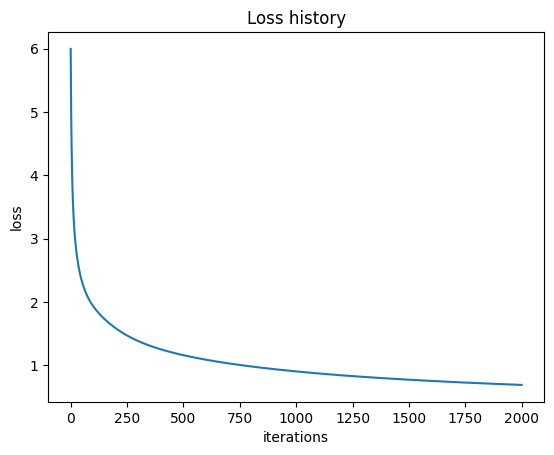

In [51]:
plt.plot(loss_history)
plt.title('Loss history')
plt.xlabel('iterations')
plt.ylabel('loss');

При увеличении количества эпох и настройке скорости обучения алгоритм мог бы
показать более высокий результат. При этом очевидно, что модель, которую мы
создали в рамках вводного курса в библиотеке Keras, обучилась гораздо быстрее.
На занятии по стохастическому градиентному спуску мы посмотрим, как можно
ускорить работу нашего алгоритма.

## Ответы на вопросы

**Вопрос.** Чем отличается умножение матриц от векторизации?

**Ответ.** Принцип умножения матриц относится к математике и описывает правила, по которым мы умножаем два двумерных тензора. Векторизация кода — термин из программирования, который позволяет избежать использования циклов в процессе
выполнения кода.



---



**Вопрос.** Для чего нужна функция активации? Можно ли без нее обойтись?

**Ответ.** Предположим, что мы убрали функцию активации. В этом случае в каждом слое у нас остаются линейные функции. Пусть это $f(x) = 3x-2$ и $g(x)=4x+5.$

Несложно заметить, что композицией таких функций будет также линейная функция $f(g(x)) = 3(4x+5)-2 = 12x+13.$ Другими словами, в этом случае мы можем объединить все слои нейросети в один слой, что существенно ограничит гибкость
алгоритма.